# 04 - Bandpass sampling study

Purpose of notebook:
- Determine empirically the extent of spectral leakage outside f1 and f2 for chirplets that span the design constraints
- From this data, determine a bandwidth parameter for safe (from aliasing) bandpass sampling
- Perform bandpass sampling via complex demodulation and inspect I & Q (envelope and phase parts of the resampling op)
- Confirm output size is as expected
- Check spectral content of output

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, resample_poly, hilbert, convolve
import soundfile as sf

from util import pchirp, pick_bw_fc, bw_fc_to_f1f2, pick_val
from util import MAX_DUR_MS, MIN_DUR_MS, MAX_DEGREE, MIN_DEGREE, FS

%matplotlib widget

plt.close('all')

### Method

- Spectral leakage will be determined by the kernel (filter) frequency content
- Each kernel will thus be zero padded to a common length to increase freq resolution and simply FFT'ed to inspect content compared to intended f1 - f2 range

In [2]:
# Helper method - compute actual bandwidth of signal
#  - finds X dB down frequencies in response, where X is threshold compared to 0 dB

def get_bw_actual(signal, threshold_dB, samplerate=16000):
    f = np.fft.rfftfreq(len(signal), 1. / FS)
    x = np.fft.rfft(signal)
    X = 20 * np.log10(np.abs(x) + 1e-12)
    X -= np.max(X)
    idx = np.argmax(X)

    if np.min(X[:idx]) > threshold_dB:
        # print("Left side of fc did not reach threshold")
        return (np.nan, np.nan)
    if np.min(X[idx:]) > threshold_dB:
        # print("Right side of fc did not reach threshold")
        return (np.nan, np.nan)
        
    i = idx
    a = 0
    while i > 0 and a > threshold_dB:
        i -= 1
        a = X[i]
    f1 = f[i]
    i = idx
    a = 0
    while i < len(f) and a > threshold_dB:
        i += 1
        a = X[i]
    f2 = f[i]

    return (f1, f2)

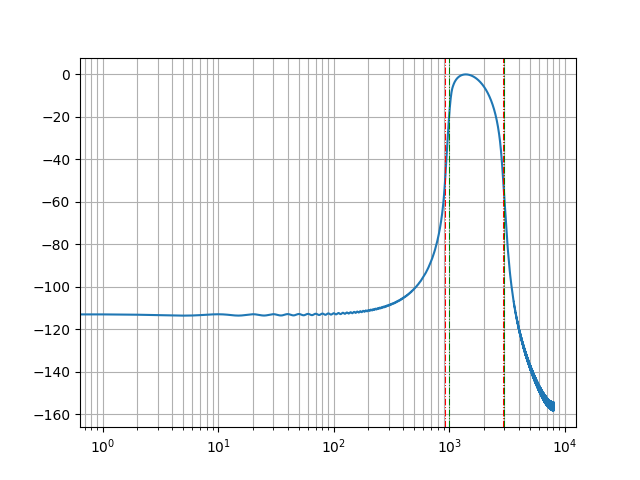

In [3]:
# Test get_bw_actual on example chirplet

T = 1.0
ch = pchirp(1000., 3000., 100., 2.)
chp = np.zeros(int(FS * T))
chp[:len(ch)] = ch
L = len(chp)

f = np.fft.rfftfreq(L, 1. / FS)
x = np.fft.rfft(chp)
X = 20 * np.log10(np.abs(x) + 1e-12)
X -= np.max(X)

F1, F2 = get_bw_actual(chp, -50)

plt.semilogx(f, X)
plt.axvline(F1, color='r', linestyle='-.', linewidth=0.75)
plt.axvline(F2, color='r', linestyle='-.', linewidth=0.75)
plt.axvline(1000., color='g', linestyle='-.', linewidth=0.75)
plt.axvline(3000., color='g', linestyle='-.', linewidth=0.75)
plt.grid(which='both')
plt.show()

In [4]:
# Generate many chirplets and collect data
N = 2500
data = []

for i in range(N):
    if i % 1000 == 0:
        print(f"Iter: {i:>4} / {N}")

    # Generate chirp
    dur = pick_val(MIN_DUR_MS, MAX_DUR_MS)
    deg = pick_val(MIN_DEGREE, MAX_DEGREE)
    bw, fc = pick_bw_fc()
    f1, f2 = bw_fc_to_f1f2(bw, fc)
    ch = pchirp(f1, f2, dur, deg)
    chp = np.pad(ch, (0, int(FS * T - len(ch))))

    # Compute bw with leakage
    F1_40, F2_40 = get_bw_actual(chp, -40)
    F1_50, F2_50 = get_bw_actual(chp, -50)
    F1_60, F2_60 = get_bw_actual(chp, -60)

    # Store
    d = {}
    d["duration_ms"] = dur
    d["degree"] = deg
    d["bw"] = bw
    d["fc"] = fc
    d["f1f2"] = (f1, f2)
    d["f1f2_40"] = (F1_40, F2_40)
    d["f1f2_50"] = (F1_50, F2_50)
    d["f1f2_60"] = (F1_60, F2_60)

    data.append(d)

Iter:    0 / 2500
Iter: 1000 / 2500
Iter: 2000 / 2500


In [5]:
# Analysis - Threshold NaNs

nan_count = np.array([0, 0, 0])

for d in data:
    if np.isnan(d["f1f2_40"][0]):
        nan_count[0] += 1
    if np.isnan(d["f1f2_50"][0]):
        nan_count[1] += 1
    if np.isnan(d["f1f2_60"][0]):
        nan_count[2] += 1

print('Percentage NaNs: 40, 50, 60 dB:')
print('    ', f"{np.round(100. * nan_count / N, 1)}")

Percentage NaNs: 40, 50, 60 dB:
     [ 3.6  7.2 14.5]


## Threshold . . .
- Too many Nans if threshold is too strict: use -40 dB

In [6]:
# Analysis - BW widening and fc distortion

max_bwe = 0
imax_bwe = 0
max_fc_shift = 0
imax_fc_shift = 0

for i, d in enumerate(data):
    bw = np.ceil(d["bw"])
    f1e, f2e = np.ceil(d["f1f2_40"])
    bwe = np.abs(f2e - f1e)

    fce = (f1e + f2e) / 2
    diff = np.ceil(np.abs(fce - d["fc"]))
    
    if bwe > bw and bwe > max_bwe:
        print(f"bw0: {bw:>4}, bwe: {bwe:>4}, idx: {i}") 
        max_bwe = bwe
        imax_bwe = i
    
    if diff > max_fc_shift:
        max_fc_shift = diff
        imax_fc_shift = i
        print(f"max fc dist: {max_fc_shift}, idx: {i}")

bw0: 1234.0, bwe: 1351.0, idx: 0
max fc dist: 88.0, idx: 0
max fc dist: 118.0, idx: 4
max fc dist: 129.0, idx: 8
bw0: 1716.0, bwe: 1751.0, idx: 12
max fc dist: 166.0, idx: 20
bw0: 1734.0, bwe: 1842.0, idx: 21
bw0: 1612.0, bwe: 1893.0, idx: 27
bw0: 1736.0, bwe: 1935.0, idx: 92
bw0: 1900.0, bwe: 2207.0, idx: 127
max fc dist: 170.0, idx: 302
max fc dist: 202.0, idx: 443
bw0: 1795.0, bwe: 2228.0, idx: 833
max fc dist: 204.0, idx: 1616
max fc dist: 208.0, idx: 2146


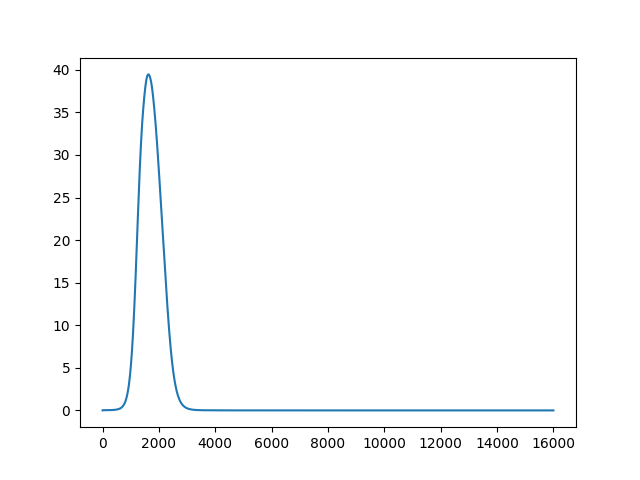

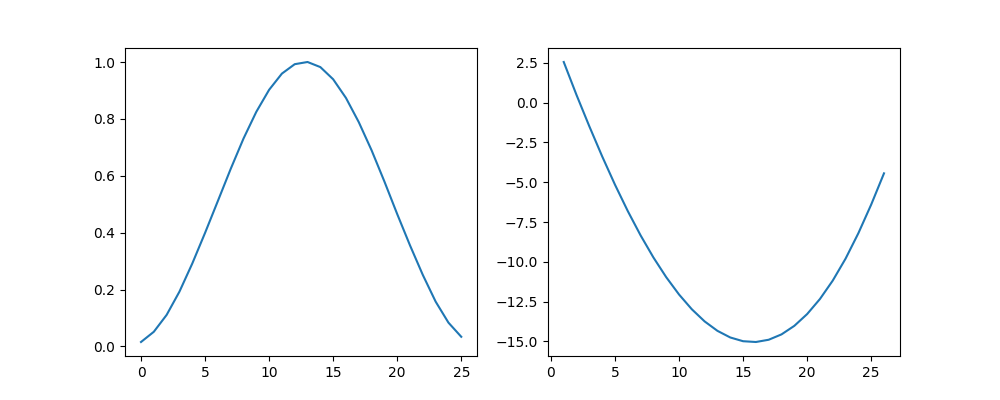

In [7]:
# Complex demodulation bandpass sampling - first on padded chirplet

from fractions import Fraction

frac = Fraction(2400, FS).limit_denominator(1000)
up, down = frac.numerator, frac.denominator

# Recreate chirplet from previous test w max empirical bw / fc distortion
idx = imax_bwe
# idx = imax_fc_shift

p = data[idx]
ch = pchirp(p["f1f2"][0], p["f1f2"][1], p["duration_ms"], p["degree"])
chp = np.pad(ch, (0, int(FS * T - len(ch))))

# Compute new fc
f1e, f2e = get_bw_actual(chp, -40)
fce = (f1e + f2e) / 2

# Hilbert transform before shifting and downsampling to avoid potential overlap of negative freq content with low fc chirplets
chp_hilb = hilbert(chp)

# Ensure no negative freqs
plt.figure()
plt.plot(np.abs(np.fft.fft(chp_hilb)))
plt.show()

# Complex demod - shift by fce
t = np.arange(0., T, 1 / FS)
chp_demod = chp_hilb * np.exp(-1j * 2 * np.pi * fce * t)

# Resample (can't just decimate because new FS doesn't divide into FS
chp_res = resample_poly(chp_demod, up=up, down=down)

# Plot mag and phase after demod - masking necessary because of long zero pad tail in toy example
mag = np.abs(chp_res)
threshold = 10 ** (-40 / 20) * np.max(mag)  # -40dB relative to peak
mask = mag > threshold
phase_raw = np.angle(chp_res)
phase_unwrapped = np.full_like(phase_raw, np.nan)
phase_unwrapped[mask] = np.unwrap(phase_raw[mask])

figs, axs = plt.subplots(1,2, figsize=(10, 4))
axs[0].plot(mag[mask])
axs[1].plot(phase_unwrapped)
plt.show()

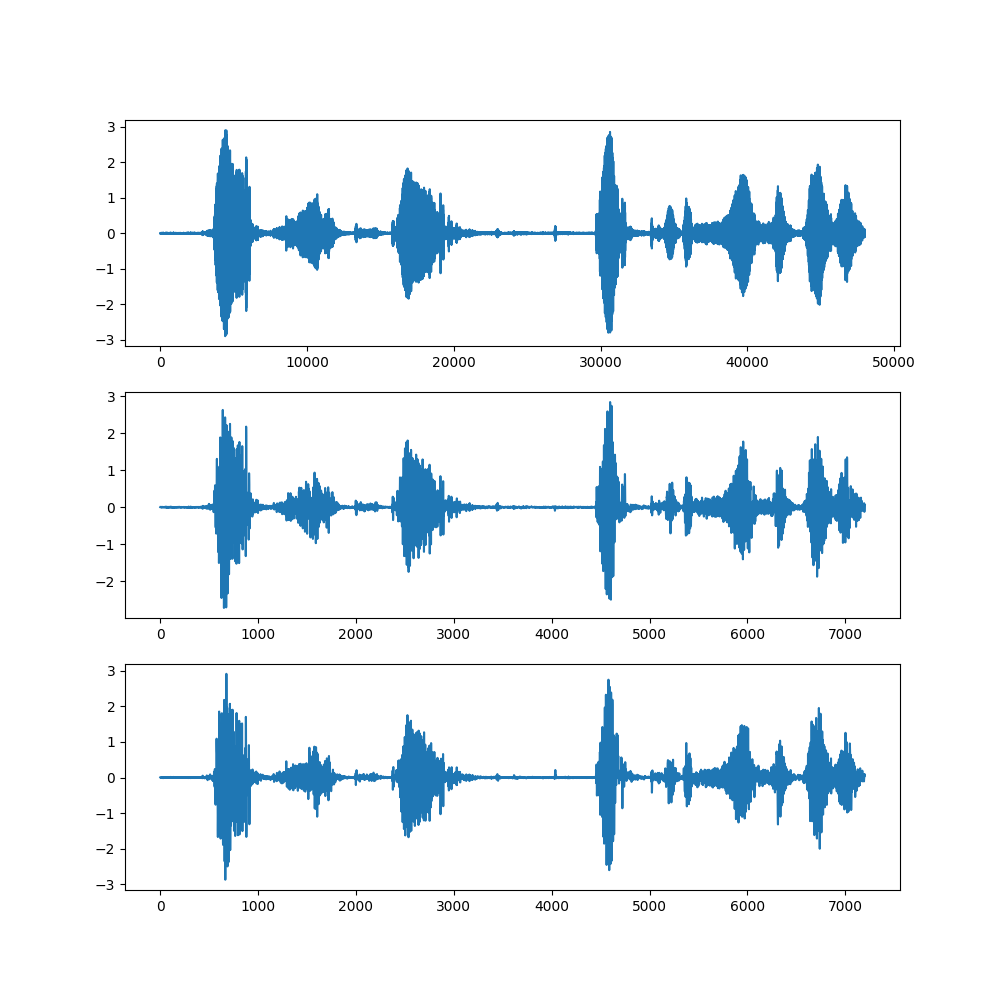

Output length: 7200
BW * duration: 7200


In [11]:
# Perform complex demod on chirplet-filtered speech

speech_path = f'/Volumes/LPM03 storage/Datasets/Audio/LibriSpeech/LibriSpeech/train-clean-100/19/198/19-198-0010.flac'
speech, sr = sf.read(speech_path)
speech = speech[:int(3 * FS)]
assert sr == FS, "Samplerate mismatch"

# Use same chirp from previous cell
y = convolve(speech, ch, mode='same')

# Hilbert
y_hilb = hilbert(y)

# Complex demod - shift by fce
t = np.arange(0., 3, 1 / FS)
y_demod = y_hilb * np.exp(-1j * 2 * np.pi * fce * t)

# Resample (can't just decimate because new FS doesn't divide into FS
y_res = resample_poly(y_demod, up=up, down=down)

# Plot check
figs, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(y)
axs[1].plot(np.real(y_res))
axs[2].plot(np.imag(y_res))
plt.show()

# Size check 
print(f"Output length: {len(y_res)}")
print(f"BW * duration: {2400 * 3}")

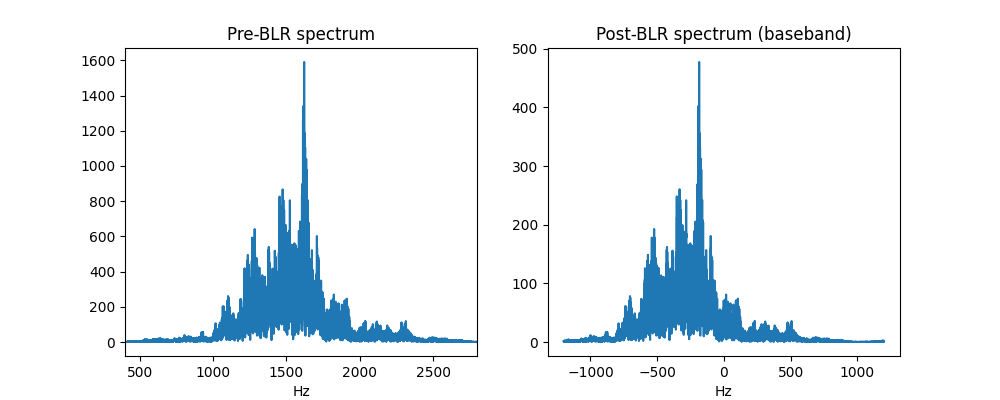

In [15]:
# Confirm spectral content of output after BLR

f_orig = np.fft.rfftfreq(len(y), 1 / FS)
Y = np.fft.rfft(y)

FS_new = FS * up / down
f_res = np.fft.fftshift(np.fft.fftfreq(len(y_res), 1 / FS_new))
YR = np.fft.fftshift(np.fft.fft(y_res))

figs, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(f_orig, np.abs(Y))
axs[0].set_title("Pre-BLR spectrum")
axs[0].set_xlabel("Hz")

axs[1].plot(f_res, np.abs(YR))
axs[1].set_title("Post-BLR spectrum (baseband)")
axs[1].set_xlabel("Hz")
plt.show()

## Findings

- Requiring an amplitude threshold of < -40 dB produces too many unusable chirplets (ones for which the threshold cannot be met)
    - Threshold set to -40 dB for finding BW from freq responses empirically
- Reducing max bandwidth (at chirp design) to 1900 and running 100000 iters (randomized chirplet params):
    - max empirically computed bandwidth at -40dB threshold: 2388
    - BP sampling with 2400 Hz should be safe under these conditions (content outside of the intended band will be at least 40 dB down)
- Within these bandwidth constraints, fc can shift 200+ Hz, making it worth computing and using in resampling
- Re: bandpass sampling, operation on both padded chirplet and example speech looks to be effective
- Output confirmed correct size `BW * duration`
- Post-BLR content looks correct